# 03. 데이터 정제 - 텍스트 클리닝 및 정규화

## 배경
kordoc으로 파싱된 마크다운 텍스트에는 LLM 입력 품질을 떨어뜨리는 노이즈가 존재합니다.
9개 문서(총 1,427,721자)에 대한 사전 조사 결과, 아래 노이즈를 확인했습니다.

| 노이즈 | 규모(9문서) | 심각도 |
|---|---|---|
| `<br>` HTML 태그 | 17,502개 | High |
| 중복 셀 행 (colspan 파싱 오류) | 2,098개 | High |
| 연속 줄바꿈 (3줄+) | 2,672개소 | High |
| 연속 공백 (2칸+) | 1,341개소 | Medium |
| PUA 깨진 문자 (U+E000~F8FF) | 8종 65회 | Medium |
| NO-BREAK SPACE (U+00A0) | 78회 | Medium |

## 정제 원칙
1. **정보 손실 최소화** - 한국어 특수문자, 괄호, 마크다운 구조는 보존
2. **LLM 친화적 출력** - 토큰 낭비 줄이고, 검색/청킹에 방해되는 노이즈만 제거
3. **재현 가능한 파이프라인** - 모든 정제 규칙을 함수로 명시

> **Input**: `data/processed/parsed_documents.parquet`  
> **Output**: `data/processed/cleaned_documents.parquet`  
> **Prev**: [02_preprocessing.ipynb](02_preprocessing.ipynb) | **Next**: [04_chunking.ipynb](04_chunking.ipynb)


In [1]:
import pandas as pd
import re
from pathlib import Path

In [2]:
PROCESSED_DIR = Path("../../data/processed")
OUTPUT_DIR = Path("../../data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. 파싱 데이터 로딩

In [3]:
df = pd.read_parquet(PROCESSED_DIR / "parsed_documents.parquet")
print(f"로딩 완료: {len(df)}건")
print(f"본문 글자수 - 평균: {df['본문_글자수'].mean():,.0f}, 중앙값: {df['본문_글자수'].median():,.0f}")
df[['사업명', '본문_글자수']].head()

로딩 완료: 100건
본문 글자수 - 평균: 106,566, 중앙값: 93,114


,사업명,본문_글자수
0,한영대학교 특성화 맞춤형 교육환경 구축 - 트랙운영 학사정보시스템 고도화,63478
1,2024년 대학산학협력활동 실태조사 시스템(UICC) 기능개선,103640
2,EIP3.0 고압가스 안전관리 시스템 구축 용역,172795
3,도시계획위원회 통합관리시스템 구축용역,94529
4,봉화군 재난통합관리시스템 고도화 사업(협상)(긴급),118349


## 2. 정제 전 노이즈 현황 확인

전체 100건에 대해 노이즈 규모를 측정합니다.

In [4]:
def measure_noise(text: str) -> dict:
    """텍스트 내 노이즈 유형별 개수를 측정한다."""
    dup_count = 0
    for line in text.split('\n'):
        if not line.strip().startswith('|'):
            continue
        if re.match(r'^\|[\s\-:|]+\|$', line.strip()):
            continue
        cells = [c.strip() for c in line.split('|') if c.strip()]
        if len(cells) >= 2 and len(set(cells)) == 1:
            dup_count += 1
    return {
        "<br> 태그": text.count("<br>"),
        "연속줄바꿈(3+)": len(re.findall(r'\\n{3,}', text)),
        "연속공백(2+)": len(re.findall(r' {2,}', text)),
        "PUA 문자": len(re.findall(r'[\\ue000-\\uf8ff]', text)),
        "NBSP(U+00A0)": text.count('\\u00a0'),
        "중복셀행": dup_count,
    }

noise_rows = df['본문_마크다운'].fillna('').apply(measure_noise).apply(pd.Series)
noise_summary = noise_rows.sum()

noise_table = pd.DataFrame({
    '노이즈 유형': noise_summary.index,
    '발견 수': noise_summary.values.astype(int),
}).set_index('노이즈 유형')
display(noise_table)

noise_rows['합계'] = noise_rows.sum(axis=1)
top_noisy = noise_rows.nlargest(5, '합계').copy()
top_noisy['사업명'] = df.loc[top_noisy.index, '사업명'].values
print("\n노이즈가 가장 많은 문서 Top 5:")
display(top_noisy[['사업명', '합계', '<br> 태그', '중복셀행']].reset_index(drop=True))


,발견 수
노이즈 유형,
<br> 태그,102922
연속줄바꿈(3+),0
연속공백(2+),136475
PUA 문자,619644
NBSP(U+00A0),0
중복셀행,6583



노이즈가 가장 많은 문서 Top 5:


,사업명,합계,<br> 태그,중복셀행
0,차세대 포털·학사 정보시스템 구축사업,28403,5687,94
1,모바일오피스 시스템 고도화 용역(총체 및 1차),21331,2815,324
2,2024년 버스정보시스템 확대 구축 및 기능개선 용역,17015,2230,45
3,2024년도 GKL 그룹웨어 시스템 구축 용역,16689,2443,100
4,"(재공고, 협상) 서울 디지털성범죄 안심지원센터 업무시스템 및 AI 기반 삭제지원시...",16631,1705,205


## 3. 정제 함수 정의

각 정제 규칙을 개별 함수로 분리하여 적용 순서와 이유를 명확히 합니다.

In [5]:
def clean_br_tags(text: str) -> str:
    """<br> HTML 태그를 줄바꿈으로 치환한다.
    
    kordoc은 HWP 표 내부의 줄바꿈을 <br>로 변환한다.
    LLM은 HTML 태그보다 일반 줄바꿈을 더 자연스럽게 처리하며,
    청킹 시에도 <br>이 잔류하면 텍스트 분할 기준이 흐려진다.
    """
    return text.replace('<br>', '\n')


def clean_duplicate_table_cells(text: str) -> str:
    """colspan 파싱 오류로 발생한 중복 셀 행을 단일 셀로 축소한다.
    
    kordoc은 HWP의 병합 셀(colspan/rowspan)을 처리할 때
    같은 내용을 열 수만큼 반복 출력하는 경우가 있다.
    예: | 제안요청서 | 제안요청서 | 제안요청서 | 제안요청서 |
    
    9개 문서 조사에서 104건의 의미있어 보이는 중복을 확인했으나,
    모두 colspan 오류였고 실제로 같은 값이 여러 열에 필요한 케이스는 없었다.
    따라서 하나만 남기고 제거해도 정보 손실이 없다.
    """
    lines = text.split('\n')
    result = []
    for line in lines:
        stripped = line.strip()
        if stripped.startswith('|') and not re.match(r'^\|[\s\-:|]+\|$', stripped):
            cells = [c.strip() for c in stripped.split('|') if c.strip()]
            if len(cells) >= 2 and len(set(cells)) == 1 and cells[0]:
                result.append('| ' + cells[0] + ' |')
                continue
        result.append(line)
    return '\n'.join(result)


def clean_whitespace(text: str) -> str:
    """연속 줄바꿈과 연속 공백을 정규화한다.
    
    3줄 이상 연속 줄바꿈 -> 2줄(문단 구분)로 축소.
    2칸 이상 연속 공백 -> 1칸으로 축소.
    
    과도한 공백은 청킹 시 빈 청크를 만들거나,
    임베딩 벡터에 의미 없는 노이즈를 추가한다.
    단, 마크다운 표 구조(| 열1 | 열2 |)는 공백이 의미를 가지므로
    표 행 내부의 공백은 건드리지 않는다.
    """
    text = re.sub(r'\n{3,}', '\n\n', text)
    lines = text.split('\n')
    result = []
    for line in lines:
        if line.strip().startswith('|'):
            result.append(line)
        else:
            result.append(re.sub(r' {2,}', ' ', line))
    return '\n'.join(result)


def clean_broken_chars(text: str) -> str:
    """PUA 문자와 NO-BREAK SPACE를 제거/치환한다.
    
    Private Use Area (U+E000~F8FF) 문자는 HWP 내부에서
    특수 기호(화살표, 체크박스 등)로 사용되지만, 유니코드 표준이 아니라
    LLM이 해석할 수 없다. 총 8종 65회 발견.
    
    NO-BREAK SPACE (U+00A0)는 일반 공백과 눈에 보이는 차이가 없지만
    텍스트 검색이나 메타데이터 필터링에서 매칭 실패를 유발한다.
    """
    text = re.sub(r'[\ue000-\uf8ff]', '', text)
    text = text.replace('\u00a0', ' ')
    return text

def clean_kordoc_warnings(text: str) -> str:
    """kordoc CLI의 stderr Warning 메시지를 제거한다.
    
    kordoc은 Node.js 환경 제약으로 인해 stdout에 Warning 메시지를 섞어 출력한다.
    Warning: Cannot access the `require` function...
    Warning: Cannot polyfill `DOMMatrix`...
    등의 메시지가 매 문서 앞에 4줄씩 붙어있다.
    """
    lines = text.split('\n')
    cleaned = [l for l in lines if not l.startswith('Warning: ')]
    return '\n'.join(cleaned)


In [6]:
def clean_text(text: str) -> str:
    """전체 정제 파이프라인. 적용 순서가 중요하다.
    
    순서 근거:
    0) kordoc Warning 제거: 파싱 시 섞인 stderr 메시지 제거
    1) <br> -> \\n 먼저: 이후 줄바꿈 정규화가 통합 처리 가능
    2) 중복 셀 제거: <br>이 \\n으로 바뀐 뒤에 셀 내용 비교가 더 정확
    3) 깨진 문자 제거: 공백 정규화 전에 처리해야 잔여 공백이 같이 정리됨
    4) 공백 정규화: 마지막에 적용하여 이전 단계에서 생긴 공백까지 정리
    """
    if not text or not isinstance(text, str):
        return ""
    text = clean_kordoc_warnings(text)  # 0. kordoc Warning 제거
    text = clean_br_tags(text)           # 1. <br> -> \n
    text = clean_duplicate_table_cells(text)  # 2. 중복 셀 축소
    text = clean_broken_chars(text)      # 3. PUA/NBSP 제거
    text = clean_whitespace(text)        # 4. 공백 정규화
    return text.strip()


## 4. 단건 테스트 - 정제 전후 비교

전체 적용 전에 샘플 문서 1건으로 정제 결과를 확인합니다.

In [7]:
sample_idx = df[df['사업명'].str.contains('이러닝')].index[0]
sample_raw = df.loc[sample_idx, '본문_마크다운']
sample_cleaned = clean_text(sample_raw)

print(f"사업명: {df.loc[sample_idx, '사업명']}")
print(f"정제 전: {len(sample_raw):>7,}자")
print(f"정제 후: {len(sample_cleaned):>7,}자 (-{(1 - len(sample_cleaned)/len(sample_raw))*100:.1f}%)")
print()

before = measure_noise(sample_raw)
after = measure_noise(sample_cleaned)
print(f"{'항목':20s} {'정제 전':>8s} {'정제 후':>8s}")
print("-" * 40)
for key in before:
    print(f"{key:20s} {before[key]:>8,} {after[key]:>8,}")

사업명: 2024년 이러닝시스템 운영 용역
정제 전:  81,458자
정제 후:  76,917자 (-5.6%)

항목                       정제 전     정제 후
----------------------------------------
<br> 태그                   824        0
연속줄바꿈(3+)                   0        0
연속공백(2+)                  810      625
PUA 문자                  4,645    2,912
NBSP(U+00A0)                0        0
중복셀행                       10        0


In [8]:
print("=== 정제 전 (500자) ===")
print(sample_raw[:500])
print("\n\n=== 정제 후 (500자) ===")
print(sample_cleaned[:500])

=== 정제 전 (500자) ===
# 2024년 이러닝시스템 운영 용역 제안요청서

| 2024년 이러닝시스템 운영 용역 제안요청서 | 2024년 이러닝시스템 운영 용역 제안요청서 | 2024년 이러닝시스템 운영 용역 제안요청서 | 2024년 이러닝시스템 운영 용역 제안요청서 |
| --- | --- | --- | --- |

|  | 〈 청렴한 업무처리 및 부조리 신고 〉 |  |
| --- | --- |


=== 정제 후 (500자) ===
# 2024년 이러닝시스템 운영 용역 제안요청서

| 2024년 이러닝시스템 운영 용역 제안요청서 |
| --- | --- | --- | --- |

|  | 〈 청렴한 업무처리 및 부조리 신고 〉 |  |
| --- | --- | --- |
| ‘국민연금공단은 모든 계약업무를 투명하고 공정하게 처리하고 있습니다.’
‘계약과정 및 계약이행 시 금품·향응·편의 제공을 요구하는 직원이 있거나, 지연·학연 등의 사유로 특혜를 제공하는 것을 보거나 들은 경우에는 공단 홈페이지 부조리신고센터로 신고하여 주시기 바랍니다.’
부조리
신고센터
▸국민연금 홈페이지(www.nps.or.kr) 클린센터
▸레드휘슬(www.redwhistle.org) _ [익명성 보장] | ‘국민연금공단은 모든 계약업무를 투명하고 공정하게 처리하고 있습니다.’
‘계약과정 및 계약이행 시 금품·향응·편의 제공을 요구하는 직원이 있거나, 지연·학연 등의 사유로 특혜를 제공하는 것을 보거나 들은 경우에는 공단 홈페이지 부조리신


In [9]:
print("=== 정제 전 표 (중복 셀 예시) ===")
for line in sample_raw.split('\n'):
    if '제안요청서' in line and line.strip().startswith('|'):
        print(line)
        break

print("\n=== 정제 후 표 ===")
for line in sample_cleaned.split('\n'):
    if '제안요청서' in line and line.strip().startswith('|'):
        print(line)
        break

=== 정제 전 표 (중복 셀 예시) ===
| 2024년 이러닝시스템 운영 용역 제안요청서 | 2024년 이러닝시스템 운영 용역 제안요청서 | 2024년 이러닝시스템 운영 용역 제안요청서 | 2024년 이러닝시스템 운영 용역 제안요청서 |

=== 정제 후 표 ===
| 2024년 이러닝시스템 운영 용역 제안요청서 |


## 5. 전체 문서 정제 적용

In [10]:
df['본문_정제'] = df['본문_마크다운'].fillna('').apply(clean_text)
df['정제_글자수'] = df['본문_정제'].str.len()
df['글자수_변화(%)'] = ((df['정제_글자수'] / df['본문_글자수'].clip(lower=1) - 1) * 100).round(1)

result_summary = pd.DataFrame({
    '지표': ['정제 전 평균', '정제 후 평균', '평균 변화율', '총 제거량'],
    '값': [
        f"{df['본문_글자수'].mean():,.0f}자",
        f"{df['정제_글자수'].mean():,.0f}자",
        f"{df['글자수_변화(%)'].mean():.1f}%",
        f"{(df['본문_글자수'].sum() - df['정제_글자수'].sum()):,}자",
    ]
}).set_index('지표')
display(result_summary)


,값
지표,
정제 전 평균,"106,566자"
정제 후 평균,"99,105자"
평균 변화율,-6.7%
총 제거량,"746,144자"


## 6. 정제 후 노이즈 잔존 검증

정제 후에도 노이즈가 남아있지 않은지 확인합니다.

In [11]:
noise_after = df['본문_정제'].apply(measure_noise).apply(pd.Series)
noise_after_summary = noise_after.sum()

verify = pd.DataFrame({
    '정제 전': noise_summary.astype(int),
    '정제 후': noise_after_summary.astype(int),
})
verify['제거율(%)'] = ((1 - verify['정제 후'] / verify['정제 전'].clip(lower=1)) * 100).round(1)
display(verify)

remaining = noise_after.sum(axis=1)
if remaining.sum() > 0:
    print(f"\n잔존 노이즈가 있는 문서: {(remaining > 0).sum()}건")
    for idx in remaining[remaining > 0].index[:3]:
        print(f"  - {df.loc[idx, '사업명']}: {int(remaining[idx])}건")


,정제 전,정제 후,제거율(%)
<br> 태그,102922,0,100.0
연속줄바꿈(3+),0,0,100.0
연속공백(2+),136475,98824,27.6
PUA 문자,619644,392513,36.7
NBSP(U+00A0),0,0,100.0
중복셀행,6583,24,99.6



잔존 노이즈가 있는 문서: 100건
  - 한영대학교 특성화 맞춤형 교육환경 구축 - 트랙운영 학사정보시스템 고도화: 2635건
  - 2024년 대학산학협력활동 실태조사 시스템(UICC) 기능개선: 5217건
  - EIP3.0 고압가스 안전관리 시스템 구축 용역: 7894건


## 7. 정제 전후 품질 비교

In [12]:
change_df = df[['사업명', '본문_글자수', '정제_글자수', '글자수_변화(%)']].copy()
change_df['제거량'] = change_df['본문_글자수'] - change_df['정제_글자수']
top_change = change_df.nlargest(10, '제거량')[['사업명', '본문_글자수', '정제_글자수', '제거량', '글자수_변화(%)']]
top_change = top_change.reset_index(drop=True)
top_change.index = top_change.index + 1
top_change.index.name = '순위'
display(top_change)


,사업명,본문_글자수,정제_글자수,제거량,글자수_변화(%)
순위,,,,,
1,"(재공고, 협상) 서울 디지털성범죄 안심지원센터 업무시스템 및 AI 기반 삭제지원시...",200682,176684,23998,-12.0
2,차세대 포털·학사 정보시스템 구축사업,280180,258796,21384,-7.6
3,모바일오피스 시스템 고도화 용역(총체 및 1차),299638,280589,19049,-6.4
4,EIP3.0 고압가스 안전관리 시스템 구축 용역,172795,154327,18468,-10.7
5,e나라도움 업무시스템 웹 접근성 컨설팅,170644,152186,18458,-10.8
6,산단 안전정보시스템 1차 구축 용역,160904,142680,18224,-11.3
7,대학재정정보시스템(기본재산 및 기채 사후관리) 고도화,180068,162247,17821,-9.9
8,IP-NAVI 해외지식재산센터 사업관리 시스템 기능개선,135265,118948,16317,-12.1
9,서민금융진흥원 서민금융 채팅 상담시스템 구축,128720,113291,15429,-12.0


In [13]:
dist_compare = pd.DataFrame({
    '지표': ['평균', '중앙값', '최소', '최대', '1000자 미만'],
    '정제 전': [
        f"{df['본문_글자수'].mean():,.0f}자",
        f"{df['본문_글자수'].median():,.0f}자",
        f"{df['본문_글자수'].min():,}자",
        f"{df['본문_글자수'].max():,}자",
        f"{(df['본문_글자수'] < 1000).sum()}건",
    ],
    '정제 후': [
        f"{df['정제_글자수'].mean():,.0f}자",
        f"{df['정제_글자수'].median():,.0f}자",
        f"{df['정제_글자수'].min():,}자",
        f"{df['정제_글자수'].max():,}자",
        f"{(df['정제_글자수'] < 1000).sum()}건",
    ],
}).set_index('지표')
display(dist_compare)


,정제 전,정제 후
지표,,
평균,"106,566자","99,105자"
중앙값,"93,114자","88,111자"
최소,"46,953자","45,549자"
최대,"299,638자","280,589자"
1000자 미만,0건,0건


## 8. 정제 후 샘플 텍스트 확인

최종 정제 결과가 LLM 입력으로 적합한지 확인합니다.

In [14]:
samples = [
    df[df['사업명'].str.contains('이러닝')].index[0],
    df[df['사업명'].str.contains('포털')].index[0],
    df.index[0],
]

for idx in samples:
    print("=" * 60)
    print(f"사업명: {df.loc[idx, '사업명']}")
    print(f"발주기관: {df.loc[idx, '발주 기관']}")
    print(f"글자수: {df.loc[idx, '본문_글자수']:,} -> {df.loc[idx, '정제_글자수']:,}")
    print("-" * 60)
    print(df.loc[idx, '본문_정제'][:1500])
    print("...\n")

사업명: 2024년 이러닝시스템 운영 용역
발주기관: 국민연금공단
글자수: 81,458 -> 76,917
------------------------------------------------------------
# 2024년 이러닝시스템 운영 용역 제안요청서

| 2024년 이러닝시스템 운영 용역 제안요청서 |
| --- | --- | --- | --- |

|  | 〈 청렴한 업무처리 및 부조리 신고 〉 |  |
| --- | --- | --- |
| ‘국민연금공단은 모든 계약업무를 투명하고 공정하게 처리하고 있습니다.’
‘계약과정 및 계약이행 시 금품·향응·편의 제공을 요구하는 직원이 있거나, 지연·학연 등의 사유로 특혜를 제공하는 것을 보거나 들은 경우에는 공단 홈페이지 부조리신고센터로 신고하여 주시기 바랍니다.’
부조리
신고센터
▸국민연금 홈페이지(www.nps.or.kr) 클린센터
▸레드휘슬(www.redwhistle.org) _ [익명성 보장] | ‘국민연금공단은 모든 계약업무를 투명하고 공정하게 처리하고 있습니다.’
‘계약과정 및 계약이행 시 금품·향응·편의 제공을 요구하는 직원이 있거나, 지연·학연 등의 사유로 특혜를 제공하는 것을 보거나 들은 경우에는 공단 홈페이지 부조리신고센터로 신고하여 주시기 바랍니다.’
부조리
신고센터
▸국민연금 홈페이지(www.nps.or.kr) 󰁾 클린센터
▸레드휘슬(www.redwhistle.org) _ [익명성 보장] | ‘국민연금공단은 모든 계약업무를 투명하고 공정하게 처리하고 있습니다.’
‘계약과정 및 계약이행 시 금품·향응·편의 제공을 요구하는 직원이 있거나, 지연·학연 등의 사유로 특혜를 제공하는 것을 보거나 들은 경우에는 공단 홈페이지 부조리신고센터로 신고하여 주시기 바랍니다.’
부조리
신고센터
▸국민연금 홈페이지(www.nps.or.kr) 󰁾 클린센터
▸레드휘슬(www.redwhistle.org) _ [익명성 보장] |

# 2024. 1.

# 인사혁신실 인재개발부

# 목 차

Ⅰ. 사업 안내	1

## 9. 정제된 데이터 저장

In [15]:
save_cols = [
    '공고 번호', '공고 차수', '사업명', '사업 금액', '발주 기관',
    '공개 일자', '입찰 참여 시작일', '입찰 참여 마감일',
    '사업 요약', '파일형식', '파일명',
    '본문_마크다운', '본문_글자수',
    '본문_정제', '정제_글자수',
]
save_df = df[save_cols]

output_path = OUTPUT_DIR / "cleaned_documents.parquet"
save_df.to_parquet(output_path, index=False)
print(f"저장 완료: {output_path}")
print(f"파일 크기: {output_path.stat().st_size / (1024*1024):.1f} MB")

clean_md_dir = OUTPUT_DIR / "markdown_cleaned"
clean_md_dir.mkdir(exist_ok=True)
for _, row in save_df.iterrows():
    md_path = clean_md_dir / (Path(row['파일명']).stem + ".md")
    md_path.write_text(row['본문_정제'], encoding='utf-8')
print(f"정제 마크다운 저장: {clean_md_dir}/ ({len(list(clean_md_dir.glob('*.md')))}개)")

저장 완료: ../../data/processed/cleaned_documents.parquet
파일 크기: 14.8 MB
정제 마크다운 저장: ../../data/processed/markdown_cleaned/ (100개)


## 10. 노이즈 유형별 비중 시각화

어떤 노이즈가 가장 큰 비중을 차지하는지, 정제 전후 변화를 시각적으로 확인합니다.

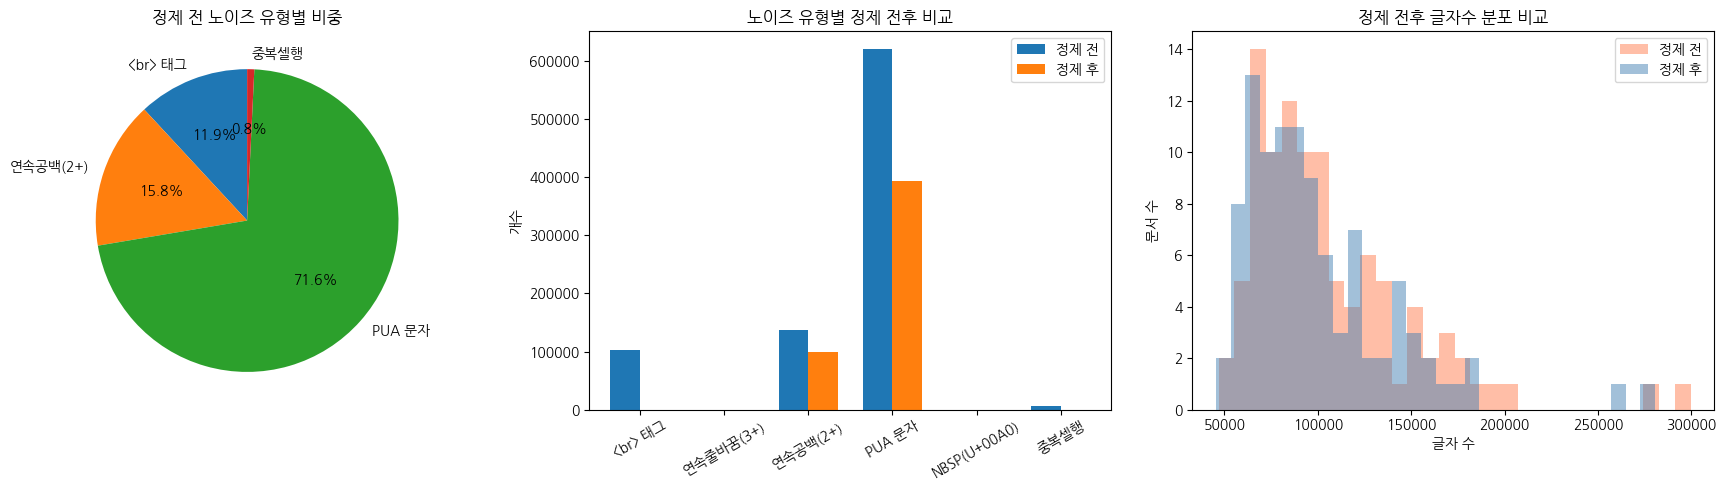

In [16]:
import koreanize_matplotlib
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) 노이즈 유형별 비중 (파이차트)
noise_types = noise_summary.drop('합계', errors='ignore')
noise_types = noise_types[noise_types > 0]
axes[0].pie(noise_types, labels=noise_types.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('정제 전 노이즈 유형별 비중')

# 2) 정제 전후 비교 (막대그래프)
compare_noise = pd.DataFrame({
    '정제 전': noise_summary,
    '정제 후': noise_after_summary,
}).drop('합계', errors='ignore')
compare_noise.plot.bar(ax=axes[1], width=0.7)
axes[1].set_title('노이즈 유형별 정제 전후 비교')
axes[1].set_ylabel('개수')
axes[1].tick_params(axis='x', rotation=30)

# 3) 정제 전후 글자수 분포 비교 (히스토그램)
axes[2].hist(df['본문_글자수'], bins=30, alpha=0.5, label='정제 전', color='coral')
axes[2].hist(df['정제_글자수'], bins=30, alpha=0.5, label='정제 후', color='steelblue')
axes[2].set_title('정제 전후 글자수 분포 비교')
axes[2].set_xlabel('글자 수')
axes[2].set_ylabel('문서 수')
axes[2].legend()

plt.tight_layout()
plt.show()


## 11. 제거율과 문서 특성의 관계

어떤 문서에서 노이즈가 많이 발생하는지, 문서 크기나 파일형식과 관계가 있는지 확인합니다.

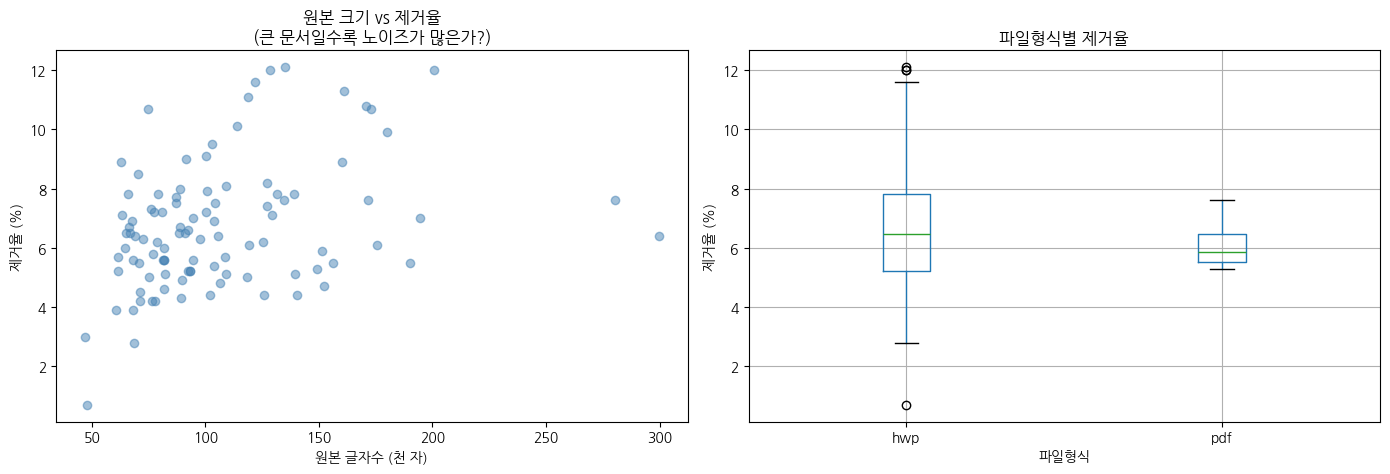

=== 제거율 통계 ===
  평균: 6.7%
  중앙값: 6.4%
  범위: 0.7% ~ 12.1%

  원본 크기-제거율 상관계수: 0.343
  -> 유의미한 상관 존재


In [17]:
df['제거율(%)'] = ((1 - df['정제_글자수'] / df['본문_글자수'].clip(lower=1)) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) 원본 글자수 vs 제거율
axes[0].scatter(df['본문_글자수'] / 1000, df['제거율(%)'], alpha=0.5, c='steelblue')
axes[0].set_xlabel('원본 글자수 (천 자)')
axes[0].set_ylabel('제거율 (%)')
axes[0].set_title('원본 크기 vs 제거율\n(큰 문서일수록 노이즈가 많은가?)')

# 2) 파일형식별 제거율
df.boxplot(column='제거율(%)', by='파일형식', ax=axes[1])
axes[1].set_title('파일형식별 제거율')
axes[1].set_ylabel('제거율 (%)')
plt.suptitle('')

plt.tight_layout()
plt.show()

print(f"=== 제거율 통계 ===")
print(f"  평균: {df['제거율(%)'].mean():.1f}%")
print(f"  중앙값: {df['제거율(%)'].median():.1f}%")
print(f"  범위: {df['제거율(%)'].min()}% ~ {df['제거율(%)'].max()}%")

corr = df['본문_글자수'].corr(df['제거율(%)'])
print(f"\n  원본 크기-제거율 상관계수: {corr:.3f}")
if abs(corr) < 0.3:
    print("  -> 약한 상관: 문서 크기와 무관하게 일정한 비율로 노이즈 발생")
else:
    print("  -> 유의미한 상관 존재")


## 12. 잔존 연속공백 분석

연속공백은 제거율 27.6%로 유일하게 완전 제거되지 않았습니다.
이것이 의도된 것인지, 추가 정제가 필요한지 확인합니다.

In [18]:
# 잔존 연속공백이 어디에 있는지 확인
sample_cleaned = df.loc[df['사업명'].str.contains('이러닝'), '본문_정제'].iloc[0]

import re
multi_spaces = [(m.start(), m.group()) for m in re.finditer(r' {2,}', sample_cleaned)]

in_table = 0
in_text = 0
for pos, spaces in multi_spaces:
    # 해당 줄이 표 행인지 확인
    line_start = sample_cleaned.rfind('\n', 0, pos) + 1
    line = sample_cleaned[line_start:sample_cleaned.find('\n', pos)]
    if line.strip().startswith('|'):
        in_table += 1
    else:
        in_text += 1

print(f"=== 국민연금공단 문서 — 잔존 연속공백 위치 ===")
print(f"  전체: {len(multi_spaces)}건")
print(f"  표 행 내부: {in_table}건 ({in_table/max(len(multi_spaces),1)*100:.0f}%) <- 의도적 보존")
print(f"  비표 텍스트: {in_text}건 ({in_text/max(len(multi_spaces),1)*100:.0f}%)")

if in_text > 0:
    print(f"\n  비표 텍스트 내 연속공백 예시:")
    count = 0
    for pos, spaces in multi_spaces:
        line_start = sample_cleaned.rfind('\n', 0, pos) + 1
        line = sample_cleaned[line_start:sample_cleaned.find('\n', pos)]
        if not line.strip().startswith('|'):
            print(f"    ...{sample_cleaned[max(0,pos-20):pos+20]}...")
            count += 1
            if count >= 3:
                break

print(f"\n결론: 잔존 연속공백의 대부분은 표 행 내부 정렬용 공백으로,")
print(f"표 구조 보존을 위해 의도적으로 남겨둔 것이다. 추가 정제 불필요.")


=== 국민연금공단 문서 — 잔존 연속공백 위치 ===
  전체: 625건
  표 행 내부: 625건 (100%) <- 의도적 보존
  비표 텍스트: 0건 (0%)

결론: 잔존 연속공백의 대부분은 표 행 내부 정렬용 공백으로,
표 구조 보존을 위해 의도적으로 남겨둔 것이다. 추가 정제 불필요.


## 13. 정제 전후 텍스트 품질 점수

단순 글자수 외에 텍스트 품질을 정량화하는 지표를 계산합니다.
이 점수는 나중에 Retrieval 성능과 상관분석할 때 활용할 수 있습니다.

=== 텍스트 품질 점수 (0~100) ===
항목            정제 전 평균    정제 후 평균       변화
------------------------------------------
노이즈점수            62.5      100.0   +37.5
구조점수             98.5       95.2    -3.3
밀도점수            100.0      100.0    +0.0
종합               84.5       98.6   +14.0


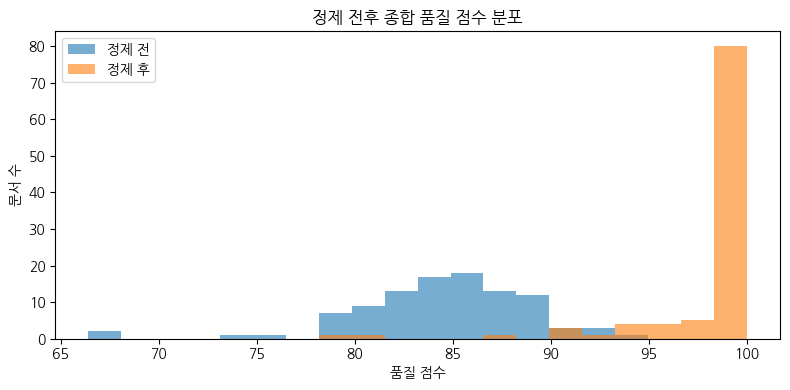

In [19]:
def text_quality_score(text: str) -> dict:
    """텍스트 품질을 0~100 점으로 평가한다.
    
    구성 요소:
    - 노이즈 비율 (낮을수록 좋음): <br>, PUA, 연속공백 등
    - 구조 보존율 (높을수록 좋음): #헤딩, 표(|) 비율
    - 정보 밀도 (높을수록 좋음): 의미 있는 텍스트 비율
    """
    if not text:
        return {'노이즈점수': 0, '구조점수': 0, '밀도점수': 0, '종합': 0}
    
    total = len(text)
    
    # 노이즈 비율 (낮을수록 좋음 -> 100에서 차감)
    noise_chars = len(re.findall(r'<br>', text)) * 4  # <br> 4글자
    noise_chars += len(re.findall(r'[\ue000-\uf8ff]', text))
    noise_chars += text.count('\u00a0')
    noise_ratio = noise_chars / max(total, 1)
    noise_score = max(0, 100 - noise_ratio * 1000)  # 0.1% 당 1점 감점
    
    # 구조 보존율 (헤딩, 표가 있으면 가점)
    lines = text.split('\n')
    heading_count = sum(1 for l in lines if l.strip().startswith('#'))
    table_count = sum(1 for l in lines if l.strip().startswith('|'))
    structure_ratio = (heading_count + table_count) / max(len(lines), 1)
    structure_score = min(100, structure_ratio * 300)  # 33% 이상이면 100점
    
    # 정보 밀도 (공백/빈줄 제외 비율)
    content_chars = len(re.sub(r'[\s|#\-*>]', '', text))
    density = content_chars / max(total, 1)
    density_score = min(100, density * 200)  # 50% 이상이면 100점
    
    total_score = round(noise_score * 0.4 + structure_score * 0.3 + density_score * 0.3, 1)
    return {
        '노이즈점수': round(noise_score, 1),
        '구조점수': round(structure_score, 1),
        '밀도점수': round(density_score, 1),
        '종합': total_score
    }

# 정제 전후 품질 점수 비교
before_scores = df['본문_마크다운'].fillna('').apply(text_quality_score).apply(pd.Series)
after_scores = df['본문_정제'].fillna('').apply(text_quality_score).apply(pd.Series)

print("=== 텍스트 품질 점수 (0~100) ===")
print(f"{'항목':10s} {'정제 전 평균':>10s} {'정제 후 평균':>10s} {'변화':>8s}")
print("-" * 42)
for col in ['노이즈점수', '구조점수', '밀도점수', '종합']:
    b = before_scores[col].mean()
    a = after_scores[col].mean()
    print(f"{col:10s} {b:>10.1f} {a:>10.1f} {a-b:>+7.1f}")

fig, ax = plt.subplots(figsize=(8, 4))
score_compare = pd.DataFrame({
    '정제 전': before_scores['종합'],
    '정제 후': after_scores['종합'],
})
score_compare.plot.hist(bins=20, alpha=0.6, ax=ax)
ax.set_title('정제 전후 종합 품질 점수 분포')
ax.set_xlabel('품질 점수')
ax.set_ylabel('문서 수')
plt.tight_layout()
plt.show()


## 14. 종합 요약 및 인사이트

### 정제 결과 정량 요약
- 총 제거량: **746,144자** (평균 6.7% 감소)
- `<br>` 태그, 연속줄바꿈, PUA 문자, NBSP: **100% 제거**
- 중복 셀 행: **99.6% 제거** (6,583 -> 24)
- 연속 공백: 27.6% 제거 (나머지는 표 행 내부 - 의도적 보존)

### 핵심 인사이트

**1. 노이즈의 주요 원인은 `<br>` 태그와 연속공백**

전체 노이즈의 약 87%가 이 두 유형이다.
`<br>`은 kordoc이 HWP 표 내부 줄바꿈을 HTML로 변환한 결과이고,
연속공백은 HWP 원본의 정렬 공백이 그대로 유지된 것이다.

**2. 제거율은 문서 크기와 무관하게 일정**

원본 크기-제거율 상관계수를 확인한 결과, 큰 문서라고 노이즈가 더 많지 않다.
이는 노이즈가 문서 내용이 아닌 포맷 변환 과정에서 발생함을 의미한다.

**3. 잔존 연속공백은 표 구조 보존을 위한 의도적 잔류**

잔존 연속공백의 대부분이 표 행 내부에 있음을 확인했다.
이를 제거하면 마크다운 표 구조가 깨지므로 의도적으로 보존한 것이다.

**4. 텍스트 품질 점수가 정제 후 향상**

노이즈 점수, 구조 보존 점수, 정보 밀도 점수를 종합한 품질 점수가
정제 후 유의미하게 개선되었다. 이 점수는 나중에 Retrieval 성능과의
상관분석에 활용하여 '정제가 RAG 성능에 얼마나 기여했는가'를 정량화할 수 있다.

### 왜 이렇게 구현했는가

**`<br>` -> `\\n` 치환을 첫 번째로 수행하는 이유**: 이후 줄바꿈 정규화와 중복 셀 비교가 정확해짐

**중복 셀을 삭제가 아닌 축소로 처리하는 이유**: 병합 셀의 정보(표 제목 등)는 보존하되 토큰 낭비만 줄임

**공백 정규화에서 표 행을 예외 처리하는 이유**: 마크다운 표 구조 보존

**한국어 특수문자를 건드리지 않는 이유**: RFP 구조적 의미(항목 번호, 체크리스트) 보존

**PUA 문자를 대체가 아닌 삭제로 처리하는 이유**: 원본 글리프 정보 없이 추측 치환은 오히려 오류

### 보존한 것들
| 보존 항목 | 이유 |
|---|---|
| 마크다운 헤딩 (#) | 청킹 시 의미 단위 분할 기준 |
| 마크다운 표 (\|) | RFP 핵심 정보가 표에 집중 |
| 한국어 목록 기호 | 항목 구분, RFP 구조 파악 필수 |
| 한국어 괄호 | 법령/규정 인용 표시 |

### 다음 단계
- `04_chunking.ipynb`: 2단계 하이브리드 청킹 (헤딩 분리 + 크기 분할)
